In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn .metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
n_samples = 1000
X = np.random.randn(n_samples, 2)
y = (X[:, 0]**2 + X[:, 1]**2 > 2).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
def train_weak_classifier(X, y, weights):
    """训练单个弱分类器"""
    # 获取数据的维度：样本数和特征数
    n_samples, n_features = X.shape
    
    # 初始化最佳参数
    best_feature = 0          # 最佳特征索引
    best_threshold = 0        # 最佳阈值
    best_polarity = 1        # 最佳极性
    min_error = float('inf') # 最小错误率，初始设为无穷大
    
    # 将标签从{0,1}转换为{-1,1}
    y = np.where(y <= 0, -1, 1)
    
    # 遍历每个特征
    for feature in range(n_features):
        # 获取当前特征的所有值
        feature_values = X[:, feature]
        # 获取所有可能的阈值（去重）
        thresholds = np.unique(feature_values)
        
        # 对每个阈值进行遍历
        for threshold in thresholds:
            # 尝试两种极性（正向和反向）
            for polarity in [-1, 1]:
                # 初始化预测结果为全1
                predictions = np.ones(n_samples)
                
                if polarity == 1:
                    # 如果特征值小于阈值，预测为-1
                    predictions[feature_values < threshold] = -1
                else:
                    # 如果特征值大于等于阈值，预测为-1
                    predictions[feature_values >= threshold] = -1
                    
                # 计算加权错误率
                error = sum(weights[y != predictions])
                
                # 如果当前错误率小于最小错误率，更新最佳参数
                if error < min_error:
                    min_error = error
                    best_feature = feature
                    best_threshold = threshold
                    best_polarity = polarity
                    
    return best_feature, best_threshold, best_polarity, min_error

In [4]:
def predict_weak_classifier(X, feature, threshold, polarity):
    """使用弱分类器进行预测"""
    predictions = np.ones(len(X))
    if polarity == 1:
        predictions[X[:, feature] < threshold] = -1
    else:
        predictions[X[:, feature] >= threshold] = -1
    return predictions

In [5]:
def adaboost_train(X, y, n_estimators=50):
    """AdaBoost训练函数"""
    n_samples = len(X)
    weights = np.ones(n_samples) / n_samples
    
    # 存储所有弱分类器的参数
    weak_classifiers = []
    alphas = []  # 弱分类器权重
    
    y = np.where(y <= 0, -1, 1)  # 转换标签为{-1, 1}
    
    for _ in range(n_estimators):
        # 训练弱分类器
        feature, threshold, polarity, error = train_weak_classifier(X, y, weights)
        
        # 计算弱分类器权重
        eps = 1e-10
        alpha = 0.5 * np.log((1 - error + eps) / (error + eps))
        
        # 保存弱分类器参数
        weak_classifiers.append((feature, threshold, polarity))
        alphas.append(alpha)
        
        # 更新样本权重
        predictions = predict_weak_classifier(X, feature, threshold, polarity)
        weights *= np.exp(-alpha * y * predictions)
        weights /= np.sum(weights)  # 归一化
        
    return weak_classifiers, alphas

In [6]:
def adaboost_predict(X, weak_classifiers, alphas):
    """AdaBoost预测函数"""
    n_samples = len(X)
    n_classifiers = len(weak_classifiers)
    predictions = np.zeros(n_samples)
    
    for alpha, (feature, threshold, polarity) in zip(alphas, weak_classifiers):
        predictions += alpha * predict_weak_classifier(X, feature, threshold, polarity)
    
    return np.sign(predictions)

In [7]:
weak_classifiers, alphas = adaboost_train(X_train, y_train, n_estimators=50)
y_pred = adaboost_predict(X_test, weak_classifiers, alphas)
accuracy = accuracy_score(y_test, (y_pred > 0).astype(int))
print(f"准确率: {accuracy:.4f}")

准确率: 0.9500


In [8]:
# 可视化决策边界函数保持不变
def plot_decision_boundary(X, y, weak_classifiers, alphas):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                        np.arange(y_min, y_max, 0.1))
    
    Z = adaboost_predict(np.c_[xx.ravel(), yy.ravel()], weak_classifiers, alphas)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
    plt.title("AdaBoost决策边界")
    plt.show()

d:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


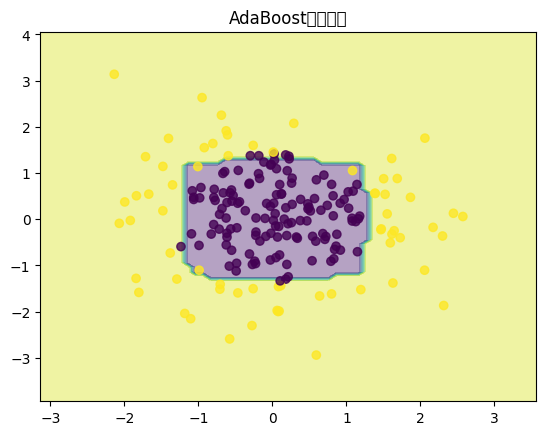

In [9]:
plot_decision_boundary(X_test, y_test, weak_classifiers, alphas)

In [13]:
import numpy as np
import plotly.express as px

# 模拟参数
n = 200  # 时间长度
phi = 0.9   # AR系数
eps = np.random.normal(0, 1, n)  # 白噪声

X = np.zeros((n,2))

In [3]:
X=X-1